In [1]:
import pandas as pd
import numpy as np
import fastf1

In [2]:
cache_path = '/Users/sukesh/Desktop/Pit/data'
fastf1.Cache.enable_cache(cache_path)

In [7]:
races = [
    (2023, 'Bahrain',       'R'),
    (2023, 'Saudi Arabia',  'R'),
    (2023, 'Australia',     'R'),
    (2023, 'Azerbaijan',    'R'),
    (2023, 'Monaco',        'R'),
    (2023, 'Spain',         'R'),
    (2023, 'Britain',       'R'),
    (2023, 'Hungary',       'R'),
    (2023, 'Belgium',       'R'),
    (2023, 'Italy',         'R'),
    (2023, 'Japan',         'R'),
    (2023, 'United States', 'R'),
    (2023, 'Canada',        'R'),
    (2023, 'Austria',       'R'),
    (2023, 'Netherlands',   'R'),
    (2023, 'Singapore',     'R')
]

In [8]:
combined = pd.concat(all_laps, ignore_index= True)

print(combined.shape)
print(combined['Race'].value_counts())

(13584, 36)
Race
Spain            1081
Canada           1055
Hungary          1041
Austria          1040
United States     922
Monaco            893
Italy             879
Britain           813
Saudi Arabia      810
Bahrain           802
Singapore         797
Azerbaijan        793
Netherlands       739
Australia         732
Japan             656
Belgium           531
Name: count, dtype: int64


In [9]:
feature_cols = [
    'LapTimeSeconds',
    'LapTimeDelta', 
    'TyreLife',
    'Position',
    'LapsRemaining'
]

WINDOW_SIZE = 10

In [10]:
print(combined.shape)
print(combined['FinalPosition'].value_counts().sort_index())
print(combined['FinalPosition'].isna().sum())

(13584, 36)
FinalPosition
1.0     783
2.0     785
3.0     773
4.0     773
5.0     773
6.0     762
7.0     769
8.0     754
9.0     743
10.0    737
11.0    729
12.0    719
13.0    702
14.0    716
15.0    706
16.0    672
17.0    595
18.0    515
19.0    400
20.0    178
Name: count, dtype: int64
0


In [14]:
combined.info()

<class 'fastf1.core.Laps'>
RangeIndex: 13584 entries, 0 to 13583
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                13584 non-null  timedelta64[ns]
 1   Driver              13584 non-null  object         
 2   DriverNumber        13584 non-null  object         
 3   LapTime             13584 non-null  timedelta64[ns]
 4   LapNumber           13584 non-null  float64        
 5   Stint               13584 non-null  float64        
 6   PitOutTime          14 non-null     timedelta64[ns]
 7   PitInTime           63 non-null     timedelta64[ns]
 8   Sector1Time         13584 non-null  timedelta64[ns]
 9   Sector2Time         13584 non-null  timedelta64[ns]
 10  Sector3Time         13584 non-null  timedelta64[ns]
 11  Sector1SessionTime  13552 non-null  timedelta64[ns]
 12  Sector2SessionTime  13584 non-null  timedelta64[ns]
 13  Sector3SessionTime  13584 non-null  timede

In [76]:
test_races = ['Britain', 'Italy']

test_mask = np.array([
    any(race in test_races for race in [combined.groupby(['Race','Driver']).groups])
])

In [71]:
sequences = []
targets = []
race_labels = []

for (race, driver), group in combined.groupby(['Race', 'Driver']):
    group = group.sort_values('LapNumber')

    if len(group) < WINDOW_SIZE:
        continue

    window = group.iloc[:WINDOW_SIZE][feature_cols].values

    target = group['FinalPosition'].iloc[0]

    sequences.append(window)
    targets.append(target)
    race_labels.append(race)
    
  
X = np.array(sequences)
y = np.array(targets)
race_labels = np.array(race_labels)  

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Example target values:", y[:5])

X shape: (299, 10, 5)
y shape: (299,)
Example target values: [ 3. 11. 15. 13.  2.]


In [72]:
baseline_preds = []

for i in range(len(X)):

    avg_position = X[i,:,3].mean()
    baseline_preds.append(round(avg_position))

baseline_preds = np.array(baseline_preds)

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_mae = mean_absolute_error(y, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y, baseline_preds))

print(f"Baseline MAE  : {baseline_mae:.2f} positions")
print(f"Baseline RMSE : {baseline_rmse:.2f} positions")

Baseline MAE  : 2.66 positions
Baseline RMSE : 3.91 positions


In [74]:
from sklearn.preprocessing import StandardScaler

n_samples, n_timesteps, n_features = X.shape

X_reshaped = X.reshape(-1, n_features)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_reshaped)

X_scaled = X_scaled.reshape(n_samples, n_timesteps, n_features)

print("X_scaled shape:", X_scaled.shape)
print("Mean per feature:", X_scaled.mean(axis=(0,1)).round(3))
print("Std per feature:", X_scaled.std(axis=(0,1)).round(3))

X_scaled shape: (299, 10, 5)
Mean per feature: [ 0. -0. -0. -0. -0.]
Std per feature: [1. 1. 1. 1. 1.]


In [77]:
test_mask = np.isin(race_labels, test_races)
X_train, X_test = X_scaled[~test_mask], X_scaled[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 261
Test samples: 38


In [79]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [80]:
model = Sequential([
    LSTM(64, return_sequences= True, input_shape = (WINDOW_SIZE, len(feature_cols))),
    Dropout(0.2),
    LSTM(32, return_sequences= False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss = 'mae',
    metrics= ['mae']
)

model.summary()

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 15,
    restore_best_weights= True
)

history = model.fit(
        X_train, y_train,
    epochs=200,
    batch_size= 16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 9.8368 - mae: 9.8368 - val_loss: 9.5040 - val_mae: 9.5040
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.5272 - mae: 9.5272 - val_loss: 9.1595 - val_mae: 9.1595
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.9404 - mae: 8.9404 - val_loss: 8.5034 - val_mae: 8.5034
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.0493 - mae: 8.0493 - val_loss: 7.3637 - val_mae: 7.3637
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.9731 - mae: 6.9731 - val_loss: 6.0394 - val_mae: 6.0394
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.9510 - mae: 5.9510 - val_loss: 5.3361 - val_mae: 5.3361
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.2830 - mae: 5.2830 - val_loss: 4.9397 - val_mae: 4.9397
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9628 - mae: 4.9628 - val_loss: 4.7825 - val_mae: 4.7825
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.62

In [83]:
lstm_preds = model.predict(X_test).flatten()

lstm_preds = np.clip(lstm_preds, 1, 20)

lstm_mae  = mean_absolute_error(y_test, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_preds))

print(f"Baseline MAE  : 2.66")
print(f"LSTM MAE      : {lstm_mae:.2f}")
print(f"")
print(f"Baseline RMSE : 3.91")
print(f"LSTM RMSE     : {lstm_rmse:.2f}")
print(f"")
print(f"MAE  improvement: {2.66 - lstm_mae:.2f} positions")
print(f"RMSE improvement: {3.91 - lstm_rmse:.2f} positions")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Baseline MAE  : 2.66
LSTM MAE      : 3.83

Baseline RMSE : 3.91
LSTM RMSE     : 5.17

MAE  improvement: -1.17 positions
RMSE improvement: -1.26 positions


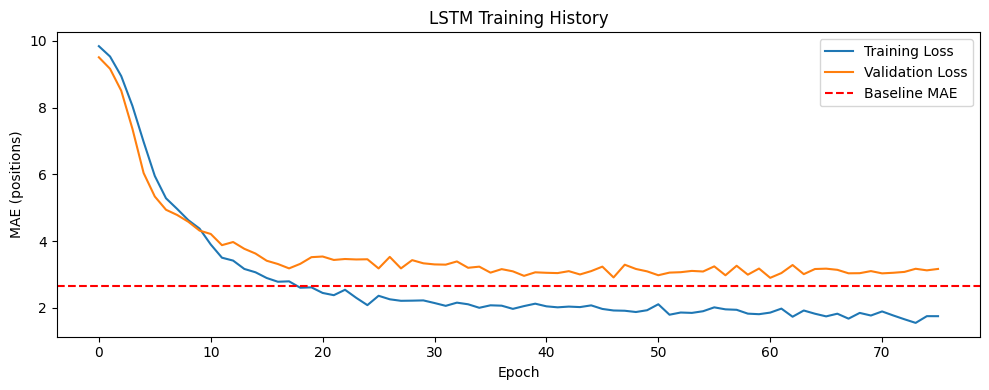

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axhline(y=2.66, color='red', linestyle='--', label='Baseline MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (positions)')
plt.title('LSTM Training History')
plt.legend()
plt.tight_layout()
# plt.savefig('assets/training_history.png', dpi=150)
plt.show()